In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_curve, roc_curve, auc, confusion_matrix, classification_report
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

In [10]:
# Load the KDD Cup 1999 dataset (Replace the path with your dataset path)
# Assuming the dataset is in CSV format
# Load the dataset
column_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
                'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
                'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
                'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
                'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
                'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
                'dst_host_srv_rerror_rate', 'label', 'drop']

# Load NSL-KDD dataset (you should download the dataset and use the correct paths)
train_data = pd.read_csv('KDDTrain+.txt', header=None, names=column_names)
test_data = pd.read_csv('KDDTest+.txt', header=None, names=column_names)

In [11]:
# Display the first few rows of the dataset to understand the structure
train_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,drop
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [12]:
# Preprocess the data: Handle categorical columns, normalization, etc.
# For this, you may need to adapt based on the specific structure of the dataset.

# For simplicity, let’s assume the dataset needs encoding for the categorical columns
categorical_columns = ['protocol_type', 'service', 'flag']

# Convert categorical variables using LabelEncoder
label_encoder = LabelEncoder()

for col in categorical_columns:
    train_data[col] = label_encoder.fit_transform(train_data[col])
    test_data[col] = label_encoder.fit_transform(test_data[col])

# Encode the label (class) column
label_encoder = LabelEncoder()
train_data['label'] = label_encoder.fit_transform(train_data['label'])
test_data['label'] = label_encoder.fit_transform(test_data['label'])

# Separating features and target variable
X_train = train_data.drop(columns=['label'])
y_train = train_data['label']
X_test = test_data.drop(columns=['label'])
y_test = test_data['label']

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Splitting the training set into training and validation sets
X_test_split, X_val_split, y_test_split, y_val_split = train_test_split(X_test, y_test, test_size=0.1, random_state=42)

In [14]:
# Create LightGBM datasets
train_data_lgb = lgb.Dataset(X_test_split, label=y_test_split)
val_data_lgb = lgb.Dataset(X_val_split, label=y_val_split, reference=train_data_lgb)

# Set up parameters for LightGBM
params = {
    'objective': 'multiclass',
    'num_class': len(label_encoder.classes_),  # Number of classes
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# Train the model
early_stopping_callback = lgb.callback.early_stopping(stopping_rounds=100)
clf = lgb.train(params,
                train_data_lgb,
                valid_sets=[train_data_lgb, val_data_lgb],
                num_boost_round=1000,
                callbacks=[early_stopping_callback])

# Predict on the test data
y_pred = clf.predict(X_test, num_iteration=clf.best_iteration)
y_pred_max = np.argmax(y_pred, axis=1)  # Get the class with the highest probability

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_max)
precision = precision_score(y_test, y_pred_max, average='macro', labels=np.unique(y_pred_max))
recall = recall_score(y_test, y_pred_max, average='macro', labels=np.unique(y_pred_max))
f1 = f1_score(y_test, y_pred_max, average='macro', labels=np.unique(y_pred_max))

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_max))




[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001565 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3012
[LightGBM] [Info] Number of data points in the train set: 20289, number of used features: 36
[LightGBM] [Info] Start training from score -3.421059
[LightGBM] [Info] Start training from score -4.137091
[LightGBM] [Info] Start training from score -6.973395
[LightGBM] [Info] Start training from score -9.917834
[LightGBM] [Info] Start training from score -2.906620
[LightGBM] [Info] Start training from score -5.105650
[LightGBM] [Info] Start training from score -9.917834
[LightGBM] [Info] Start training from score -5.065804
[LightGBM] [Info] Start training from score -7.971924
[LightGBM] [Info] Start training from score -9.224687
[LightGBM] [Info] Start training from score -4.319412
[LightGBM] [Info] Start training from score -3.119894
[LightGBM] [Info] Start training from score -7.352885
[LightGBM

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_max))

Accuracy: 0.9717885024840313
Precision: 0.6822475874027262
Recall: 0.753134915171521
F1 Score: 0.6871898647036498

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       737
           1       1.00      0.98      0.99       359
           2       0.48      0.70      0.57        20
           3       1.00      0.33      0.50         3
           4       1.00      0.97      0.99      1231
           5       0.80      0.92      0.86       133
           6       0.00      0.00      0.00         1
           7       0.92      0.77      0.84       141
           8       0.16      0.43      0.23         7
           9       0.40      1.00      0.57         2
          10       1.00      1.00      1.00       293
          11       1.00      0.96      0.98       996
          12       0.22      0.39      0.28        18
          13       0.20      0.82      0.32        17
          14       1.00      0.99      1.00      46

c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


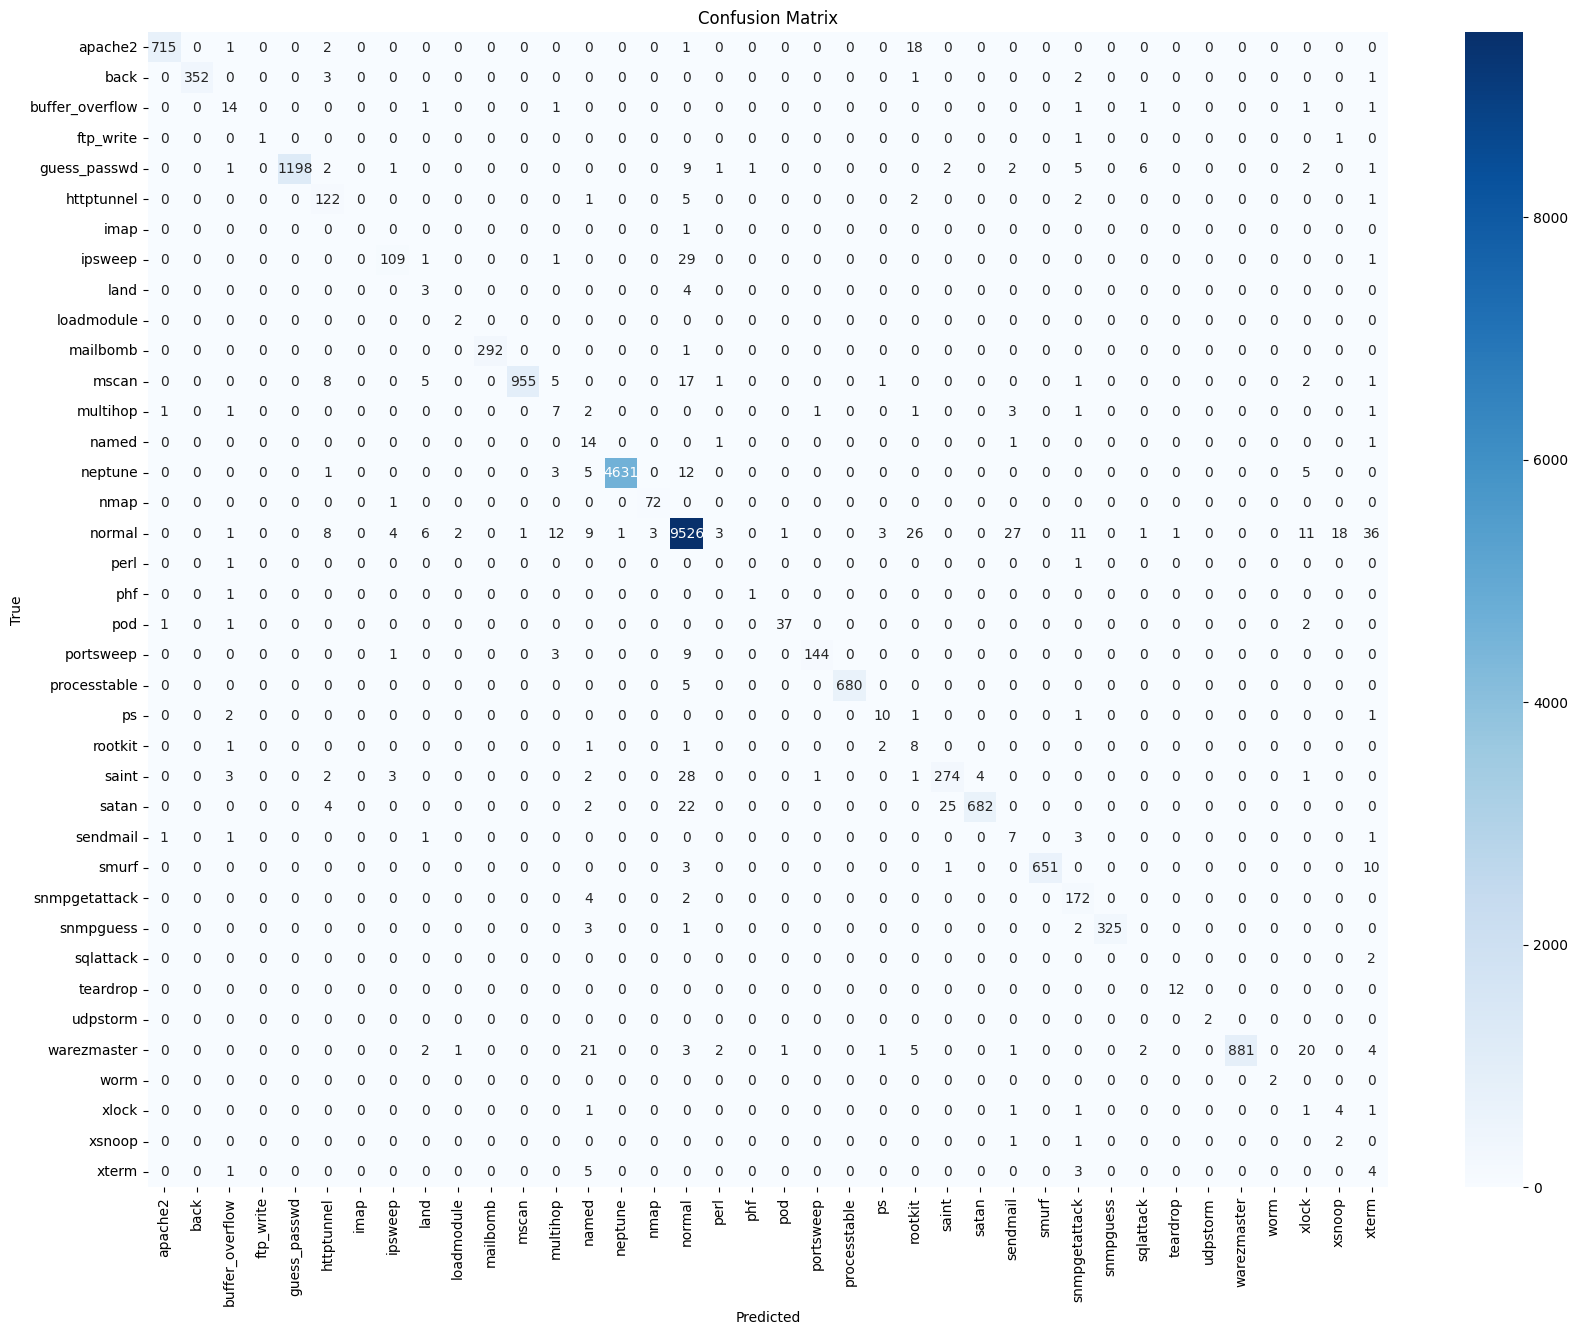

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_max)
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

